In [1]:
import sys
import numpy as np
import anndata as ad
import polars as pl
import pickle

import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')

In [3]:
active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()

In [4]:
#for l in ('acet', 'meth'):
#    bmask = cttag.obsm[f'{l}'].copy()
#    bmask.data = bmask.data > 0
#    cttag.obsm[f'{l}_masked_imp'] = cttag.obsm[f'{l}_imp'].multiply(bmask)

In [5]:
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)

mask = (cttag.obs['timep'] == "8_10h").to_numpy()

In [6]:
scit.tl.layer_pick_features(cttag, lc_meth, active_meth)
# import jax
# jax.config.update('jax_log_compiles', True)

meth_change = scit.tl.likelihood_test_on_adata(
    cttag[mask],
    cttag[~mask],
    'label',
    lc_meth
)
scit.tl.layer_pick_features(cttag, lc_acet, filter_min=0)

meth_change.write_csv('private/meth_change.csv')
# import jax
# jax.config.update('jax_log_compiles', True)

acet_change = scit.tl.likelihood_test_on_adata(
    cttag[mask],
    cttag[~mask],
    'label',
    lc_acet,
    min_base_mean = 0.2
)

acet_change.write_csv('private/acet_change.csv')

Info: Running likelihood test with minimum LFC=0.25; min_base_mean=None
Info: Running test on 592 features. Group 1 n=1114, group 2 n=815
Debug: traced _likelihood_ratio_test_many
Debug: traced fit_log_regression
Debug: traced likelihood_ratio_test
Debug: traced fit_log_regression


KeyboardInterrupt: 

In [6]:
meth_change = pl.read_csv('private/meth_change.csv').sort('base_mean').filter(pl.col('name').is_in(cttag.uns['gene_names_acet'][active_meth]))
acet_change = pl.read_csv('private/acet_change.csv').sort('base_mean')
meth_change = meth_change.filter(pl.col('group') != 'Fat Body')
acet_change = acet_change.filter(pl.col('group') != 'Fat Body')

In [7]:
meth_change

pval,score,base_mean,name,group
f64,f64,f64,str,str
0.3722054,0.408887,0.31102,"""CG14459""","""Muscle"""
0.374213,-0.431564,0.394186,"""Vps50""","""Ventral Nerve Cord"""
0.374213,-0.431564,0.394186,"""PIG-A""","""Ventral Nerve Cord"""
1.0,-0.079939,0.3988431,"""asRNA:CR45621""","""Muscle"""
1.0,0.211998,0.4012398,"""CG43638""","""Ventral Nerve Cord"""
…,…,…,…,…
1.0,0.085256,16.562061,"""opa""","""Muscle"""
1.0,0.136711,16.676006,"""Optix""","""Muscle"""
1.0,0.052024,18.40969,"""D""","""Ventral Nerve Cord"""


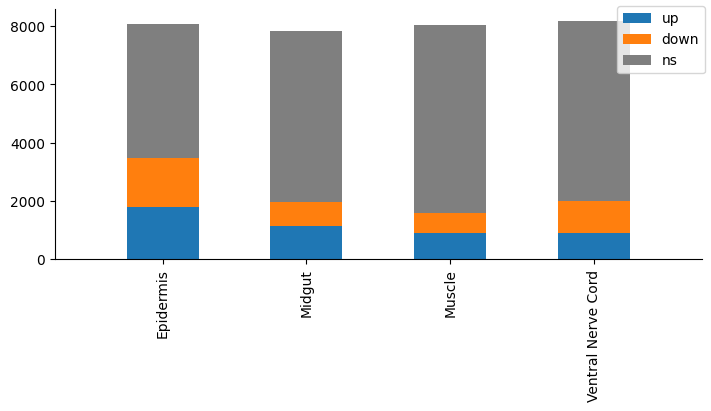

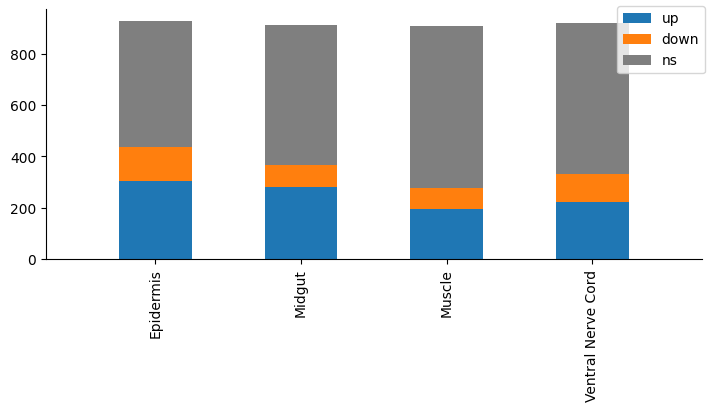

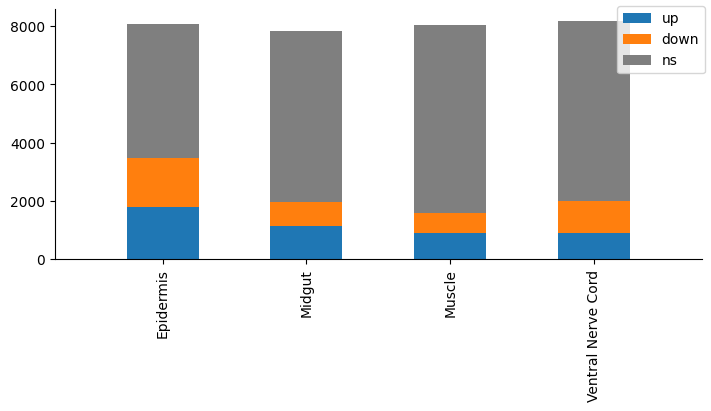

In [43]:
scit.set_defaults(figsize=(7,4))
MIN_LFC = 0.2
MIN_PVAL = 0.1
scit.adv.pl.differential_dynamics(
    meth_change,
    activity_threshold=0.6,
    lfc_threshold=MIN_LFC,
    alpha=MIN_PVAL,
    active_only=True,
    show=False
)#.savefig('private/newest/figures/meth_bar_change.pdf')
scit.adv.pl.differential_dynamics(
    acet_change,
    activity_threshold=0.7,
    lfc_threshold=MIN_LFC,
    alpha=MIN_PVAL,
    active_only=True,
    show=False
)#.savefig('private/newest/figures/acet_bar_change.pdf')

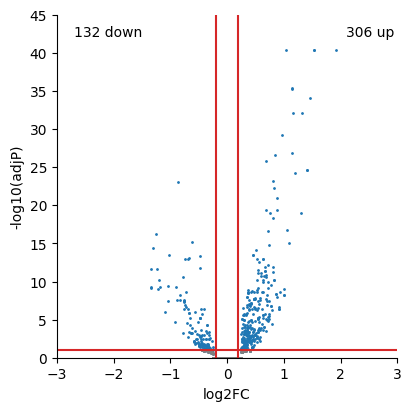

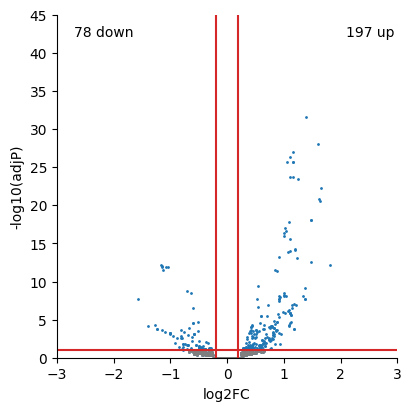

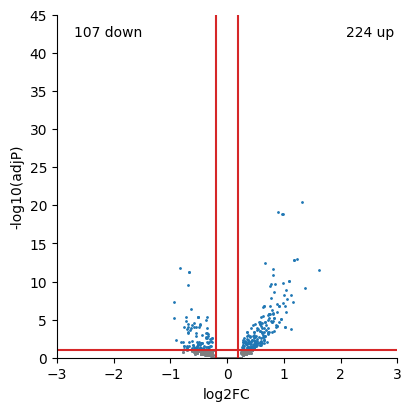

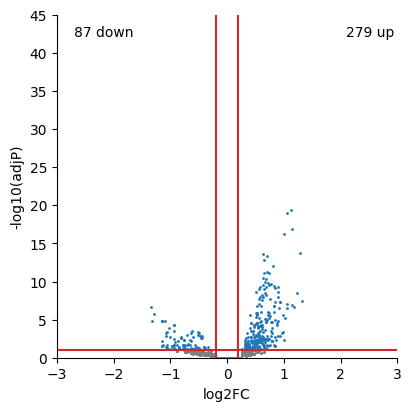

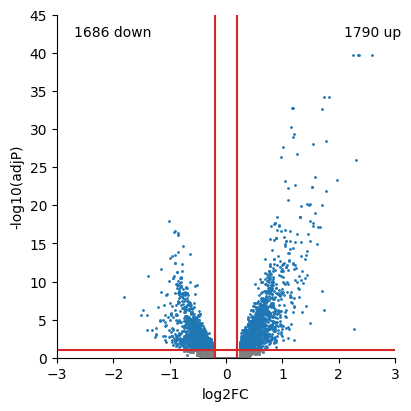

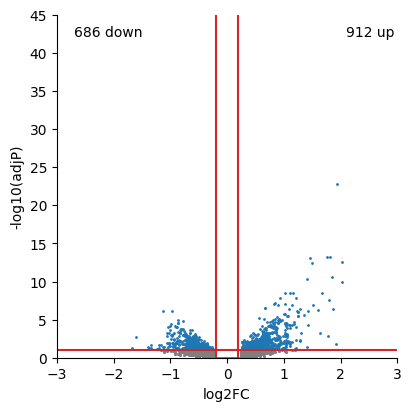

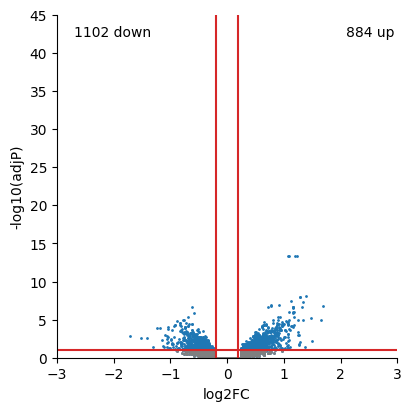

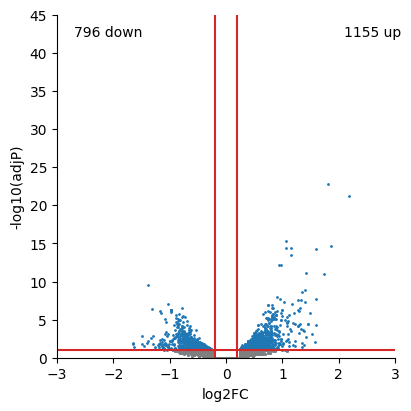

In [44]:
meth_change_f = meth_change.filter(pl.col('base_mean')>0.6).sort('score')
acet_change_f = acet_change.filter(pl.col('base_mean')>0.7).sort('score')

scit.set_defaults(figsize=(4,4))
gs = meth_change_f['group'].unique().to_numpy()
for g in gs:
    df = meth_change_f.filter(pl.col('group')==g)
    scit.pl.volcano_plot(np.array(df['pval']), np.array(df['score']), yminmax=(0,45), min_pval=MIN_PVAL, min_lfc=MIN_LFC, show=False).savefig(f'private/newest/volcano_dyn/meth_{g}.png')


gs = acet_change_f['group'].unique().to_numpy()
for g in gs:
    df = acet_change_f.filter(pl.col('group')==g)
    scit.pl.volcano_plot(np.array(df['pval']), np.array(df['score']), yminmax=(0,45), min_pval=MIN_PVAL, min_lfc=MIN_LFC, show=False).savefig(f'private/newest/volcano_dyn/acet_{g}.png')

In [45]:
changed_acet = acet_change_f.filter(pl.col('score').abs() > MIN_LFC, pl.col('pval')<MIN_PVAL)['name'].unique().to_numpy()
changed_meth = meth_change_f.filter(pl.col('score').abs() > MIN_LFC, pl.col('pval')<MIN_PVAL)['name'].unique().to_numpy()

print("Any celltype")
print(f"changed ONLY acet={len([a for a in changed_acet if a not in changed_meth])}")
print(f"changed ONLY meth={len([a for a in changed_meth if a not in changed_acet])}")
print(f"changed      BOTH={len([a for a in changed_meth if a in changed_acet])}")

Any celltype
changed ONLY acet=5660
changed ONLY meth=329
changed      BOTH=434


In [15]:
acet_change.filter(pl.col('name')=='slbo')

pval,score,base_mean,name,group
f64,f64,f64,str,str
0.117143,0.3769453,0.598587,"""slbo""","""Ventral Nerve Cord"""
5.4099e-15,1.5971725,1.253226,"""slbo""","""Midgut"""
5.5326e-14,1.8219349,1.4881091,"""slbo""","""Muscle"""
0.0,2.259792,1.8154866,"""slbo""","""Epidermis"""


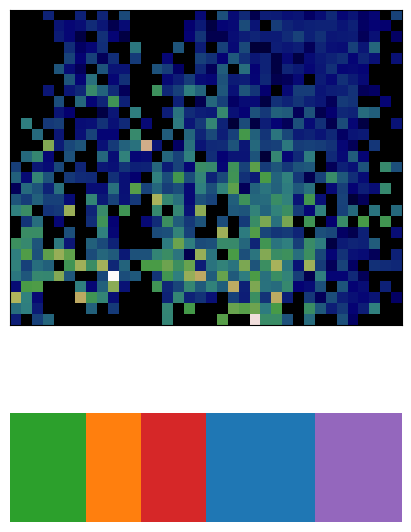

In [28]:
scit.set_defaults(figsize=(4,6))

scit.adv.pl.landscape2d(cttag, lc_acet.layer, 'slbo')

In [20]:
scit.adv.griddata_categorical(cttag, 'label', 8)

Info: Added Griddata to .uns[cat_label]


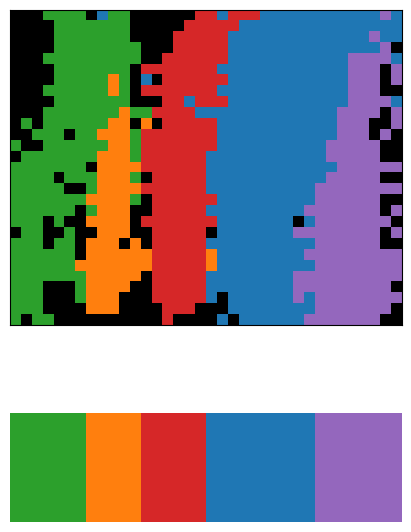

In [21]:
scit.adv.pl.categorical2d(cttag, 'cat_label')

In [22]:
scit.tl.layer_pick_features(cttag, lc_meth, filter_min=0)
scit.tl.layer_pick_features(cttag, lc_acet, filter_min=0)
scit.adv.griddata_numerical(cttag, lc_meth, min_cells=8)
scit.adv.griddata_numerical(cttag, lc_acet, min_cells=8)

Info: Picked 12518 features
Info: Picked 12518 features
Info: Added Griddata to .uns[meth]
Info: Added Griddata to .uns[acet]


In [23]:
scit.adv.griddata_apply_transformations(cttag, lc_meth.layer, (0.5,0.5), n_median_passes=1)
scit.adv.griddata_apply_transformations(cttag, lc_acet.layer, (0.5,0.5), n_median_passes=1)

Info: Added Griddata to .uns[t_meth]
Info: Added Griddata to .uns[t_acet]


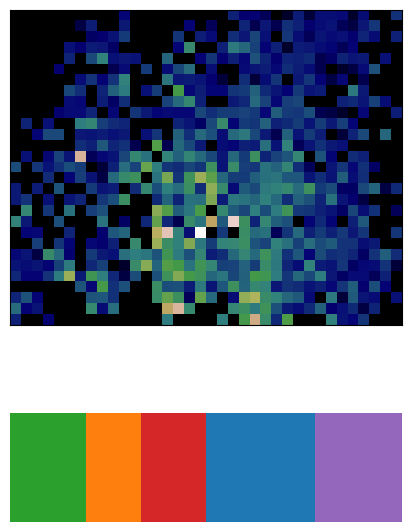

In [22]:
scit.set_defaults(figsize=(4,6))

scit.adv.pl.landscape2d(cttag, lc_meth.layer, 'nub')

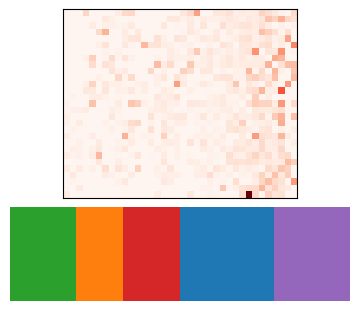

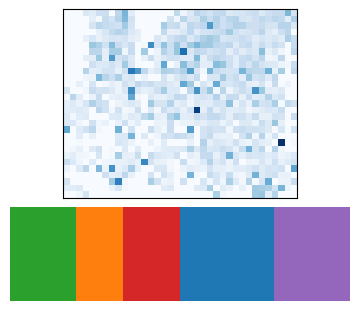

In [ ]:

scit.adv.pl.landscape2d(cttag, lc_meth.layer, 'CG13465', cmap='Reds')
scit.adv.pl.landscape2d(cttag, lc_acet.layer, 'CG13465', cmap='Blues')

In [19]:
scit.tl.summarize_data(
    cttag,
    get_current_layer_active(),
    obs_key='label_own',
    binary=True
)
scit.adv.dynamics_add_expression_data(
    cttag,
    dyn,
    cttag.uns['gene_names_acet'],
    cttag.uns[f'sum_active_class_{current_modality}_binary_active_adj_contrast_label_own'],
)

NameError: name 'get_current_layer_active' is not defined

In [11]:
# 'BobA',
# 'Brd',
# 'E(spl)m6-BFM',
# 'E(spl)malpha-BFM',
# 'Nle',
# 'Ocho',
# 'Tom',
# 'shams'

In [12]:
df = acet_change.join(meth_change, on=('name', 'group'), suffix='_meth')
df

pval,score,base_mean,name,group,pval_meth,score_meth,base_mean_meth
f64,f64,f64,str,str,f64,f64,f64
0.001426,-1.710102,0.850472,"""olf186-M""","""Ventral Nerve Cord""",0.45121,-0.608533,0.7946919
0.048638,-1.676256,0.739909,"""Nacalpha""","""Muscle""",0.529686,-0.632483,0.7057377
0.011062,-1.651803,0.7399086,"""Hers""","""Midgut""",1.0,0.052914,0.7130541
0.03736,-1.635199,0.73436,"""dally""","""Midgut""",1.0,-0.053454,1.8836187
0.002987,-1.514727,1.0484391,"""lncRNA:yar""","""Ventral Nerve Cord""",1.0,0.175727,0.856784
…,…,…,…,…,…,…,…
6.6021e-22,2.1859102,1.0021389,"""ftz-f1""","""Midgut""",0.059906,1.3317419,0.7631658
0.0,2.259792,1.8154866,"""slbo""","""Epidermis""",0.096361,0.493235,1.3462839
0.00016,2.262141,0.837945,"""sog""","""Epidermis""",1.0,0.156184,0.881902


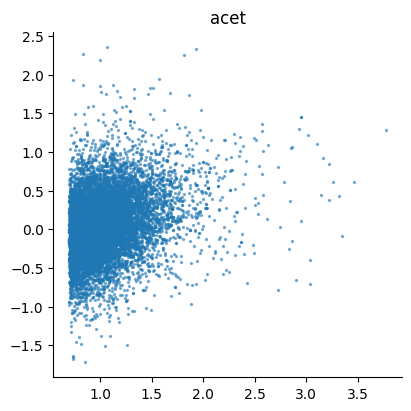

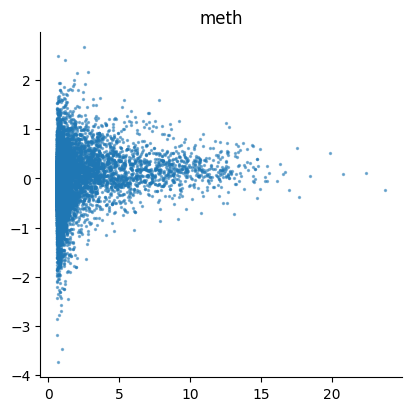

In [13]:
scit.set_defaults(figsize=(4,4))
f = scit.pl.int.scatter([np.c_[
    df['base_mean'].to_numpy(),
    df['score'].to_numpy()
]], alpha=0.5, s=2, title='acet', show=False)
scit.set_defaults(figsize=(4,4))
f = scit.pl.int.scatter([np.c_[
    df['base_mean_meth'].to_numpy(),
    df['score_meth'].to_numpy()
]], title="meth", alpha=0.5, s=2, show=False)


Pvalue: 1.4820091506809278e-25


(-2.5, 2.5)

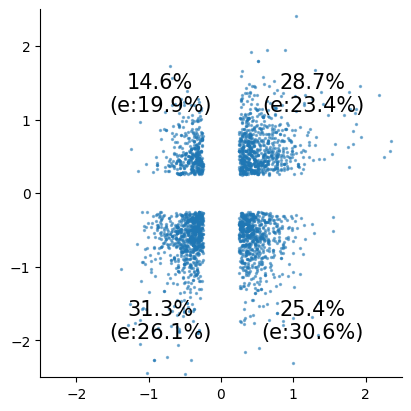

In [18]:
from src.plotting._quadrant import plot_with_qtext
import matplotlib.pyplot as plt

scit.set_defaults(figsize=(4,4))
df = acet_change.join(meth_change, on=('name', 'group'), suffix='_meth')
df = df.filter((pl.col('pval') < 0.4) & (pl.col('pval_meth') < 0.4))

plot_with_qtext(df['score'].to_numpy(), df['score_meth'].to_numpy(), a=0.5, s=2)
ax = plt.gca()
ax.set_ylim(-2.5,2.5)
ax.set_xlim(-2.5,2.5)
#df = df.filter(pl.col('var_name').is_in(cttag.uns['gene_names_acet'][active_meth]))
#f.axes[0].scatter(df['res'].to_numpy(), df['res_meth'].to_numpy(), s=1, alpha=0.2, c='r')

(260, 8)
Pvalue: 1.1466186722025364e-05


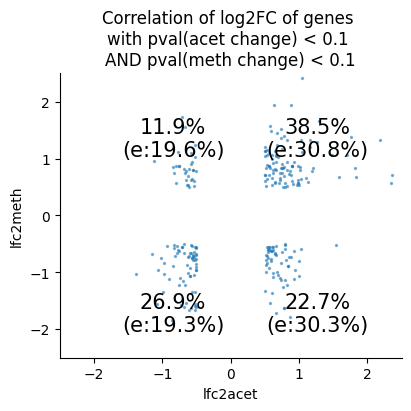

In [40]:
from src.plotting._quadrant import plot_with_qtext
import matplotlib.pyplot as plt

scit.set_defaults(figsize=(4,4))
df = acet_change.join(meth_change, on=('name', 'group'), suffix='_meth')
df = df.filter((pl.col('pval') < 0.1).and_(pl.col('pval_meth') < 0.1))
df = df.filter((pl.col('base_mean') > 0.7).and_(pl.col('base_mean_meth') > 0.6))
df = df.filter((pl.col('score').abs() > 0.5).and_(pl.col('score_meth').abs() > 0.5))
print(df.shape)

plot_with_qtext(df['score'].to_numpy(), df['score_meth'].to_numpy(), a=0.5, s=2,
                xlabel='lfc2acet', ylabel=('lfc2meth'))
ax = plt.gca()
ax.set_ylim(-2.5,2.5)
ax.set_xlim(-2.5,2.5)
ax.set_title('Correlation of log2FC of genes \nwith pval(acet change) < 0.1 \nAND pval(meth change) < 0.1')
#df = df.filter(pl.col('var_name').is_in(cttag.uns['gene_names_acet'][active_meth]))
#f.axes[0].scatter(df['res'].to_numpy(), df['res_meth'].to_numpy(), s=1, alpha=0.2, c='r')
plt.gcf().savefig('private/newest/figures/acet_meth_correlation.pdf')